In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# jacobian
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        error.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, error
        x = x_new
    return x, max_iterations, error


In [3]:
# gauss-seidel
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            # Check for convergence
        error.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, error
        x = x_new
    return x, max_iterations, error

In [4]:
A = np.array([[3,-0.1,-0.2],[0.1,7,-0.3],[0.3,-0.2,10]])
b = np.array([7.85,-19.3,71.4])
A = A.astype(float)
b = b.astype(float)
x0 = np.zeros_like(b)
max_iterations = 100

In [31]:
solution1, iterations1, error1j = jacobi(A, b, x0, 1e-3, max_iterations)
print(f"JACOBI Solution high tol: {solution1}")
print(f"Iterations: {iterations1}")
print(f"Error: {error1j}")

solution2, iterations2, error2j = jacobi(A, b, x0, 1e-6, max_iterations)
print(f"JACOBI Solution med tol: {solution2}")
print(f"Iterations: {iterations2}")
print(f"Error: {error2j}")

solution3, iterations3, error3j = jacobi(A, b, x0, 1e-9, max_iterations)
print(f"JACOBI Solution low tol: {solution3}")
print(f"Iterations: {iterations3}")
print(f"Error: {error3j}")

JACOBI Solution high tol: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3
Error: [7.140000000000001, 0.38409523809523805, 0.011214625850339832, 0.0007838526077099672]
JACOBI Solution med tol: [ 3.  -2.5  7. ]
Iterations: 6
Error: [7.140000000000001, 0.38409523809523805, 0.011214625850339832, 0.0007838526077099672, 2.3849281935106603e-05, 1.266343375494472e-06, 8.713733201659579e-08]
JACOBI Solution low tol: [ 3.  -2.5  7. ]
Iterations: 8
Error: [7.140000000000001, 0.38409523809523805, 0.011214625850339832, 0.0007838526077099672, 2.3849281935106603e-05, 1.266343375494472e-06, 8.713733201659579e-08, 2.3364679080373207e-09, 2.1947244022157975e-10]


In [32]:
solution1, iterations1, error1gs = gauss_seidel(A, b, x0, 1e-3, max_iterations)
print(f"G-S Solution high tol: {solution1}")
print(f"Iterations: {iterations1}")
print(f"Error: {error1gs}")

solution2, iterations2, error2gs = gauss_seidel(A, b, x0, 1e-6, max_iterations)
print(f"G-S Solution med tol: {solution2}")
print(f"Iterations: {iterations2}")
print(f"Error: {error2gs}")

solution3, iterations3, error3gs = gauss_seidel(A, b, x0, 1e-9, max_iterations)
print(f"G-S Solution low tol: {solution3}")
print(f"Iterations: {iterations3}")
print(f"Error: {error3gs}")

G-S Solution high tol: [ 3.00000035 -2.50000004  6.99999999]
Iterations: 3
Error: [7.0056095238095235, 0.3738898412698415, 0.00947538997430053, 3.154544153582961e-05]
G-S Solution med tol: [ 3.  -2.5  7. ]
Iterations: 4
Error: [7.0056095238095235, 0.3738898412698415, 0.00947538997430053, 3.154544153582961e-05, 3.544137046063156e-07]
G-S Solution low tol: [ 3.  -2.5  7. ]
Iterations: 6
Error: [7.0056095238095235, 0.3738898412698415, 0.00947538997430053, 3.154544153582961e-05, 3.544137046063156e-07, 1.9325110400814083e-09, 1.2023715356690445e-11]


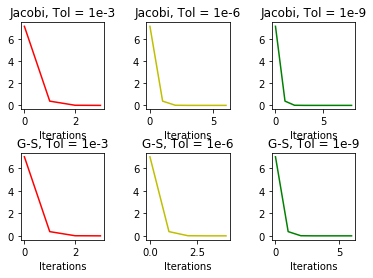

In [33]:
x1j = np.arange(len(error1j))
x2j = np.arange(len(error2j))
x3j = np.arange(len(error3j))
x1gs = np.arange(len(error1gs))
x2gs = np.arange(len(error2gs))
x3gs = np.arange(len(error3gs))

plt.subplot(2, 3, 1) # (row, column, active area)
plt.plot(x1j, error1j, 'r')
plt.title('Jacobi, Tol = 1e-3')
plt.xlabel('Iterations')
plt.subplot(2, 3, 2)
plt.plot(x2j, error2j, 'y')
plt.title('Jacobi, Tol = 1e-6')
plt.xlabel('Iterations')
plt.subplot(2, 3, 3) # (row, column, active area)
plt.plot(x3j, error3j, 'g')
plt.title('Jacobi, Tol = 1e-9')
plt.xlabel('Iterations')
plt.subplot(2, 3, 4)
plt.plot(x1gs, error1gs, 'r')
plt.title('G-S, Tol = 1e-3')
plt.xlabel('Iterations')
plt.subplot(2, 3, 5) # (row, column, active area)
plt.plot(x2gs, error2gs, 'y')
plt.title('G-S, Tol = 1e-6')
plt.xlabel('Iterations')
plt.subplot(2, 3, 6)
plt.plot(x3gs, error3gs, 'g')
plt.title('G-S, Tol = 1e-9')
plt.xlabel('Iterations')
plt.subplots_adjust(wspace=0.5)
plt.subplots_adjust(hspace=0.5)
plt.show()

In both the Jacobi and Gauss-Seidel methods, if you decrease the tolerance, the algorithm must perform more iterations to reach the higher level of accuracy. The error for all of the graphs starts at around 7. The graphs in red with the high tolerance converge the quickest, while the graphs in green take the longest.

Gauss-Seidel generally requires fewer iterations than Jacobi for any given tolerance because it incorporates updated variable values immediately within the same iteration. While both methods see an increase in computational cost as tolerance tightens, the "gap" in efficiency between the two becomes more apparent at stricter tolerance levels, with the Jacobi method taking 2 extra iterations for the error to converge to 0.